# BA820 Project — Milestone 3 (M3)
## Integration & Synergy: Strategy Clusters × Exit Pathways

### What M3 does differently from M2
In M2, team members analyzed the same dataset with different preprocessing and different analytical lenses:
- Yanlun: hierarchical clustering (Jaccard) on equipment only → concluded weak cluster structure.
- Yangze: K-Means on equipment + age → identified 4 interpretable strategy clusters with survival differences.
- Marcus: exit pathway patterns (timing + reason) → concluded structured exit modes over time.

M3 unifies preprocessing and uses controlled experiments to:
1) Resolve the clustering contradiction under the same pipeline.
2) Overlay Yangze’s strategy labels with Marcus’s exit pathway labels to test association.


##Import

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.decomposition import PCA


pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)




RANDOM_STATE = 42

## Section 1 — Problem Reframing: A Contradiction that Drives Integration

M2 produced conflicting conclusions on whether discrete “strategy types” exist:
- Hierarchical + Jaccard (Yanlun): heavy overlap in equipment choices → weak clustering structure.
- K-Means + (equipment + age) (Yangze): 4 clusters (“Hunter / Forager / Generalist / Experienced”) with survival differences.

This contradiction motivates M3 Question 1:
**Is the strategy segmentation robust, or method-dependent?**

M3 responds with controlled, apple-to-apple comparisons under one unified preprocessing pipeline.


In [33]:
BASE_URL = "https://raw.githubusercontent.com/Marcusshi/BA820-A1-08/main/data/alone_tv_show/"
survivalists = pd.read_csv(BASE_URL + "survivalists.csv")
loadouts = pd.read_csv(BASE_URL + "loadouts.csv")
episodes = pd.read_csv(BASE_URL + "episodes.csv")
print(survivalists.shape, loadouts.shape, episodes.shape)

(94, 16) (940, 6) (98, 11)


In [34]:
print("survivalists columns:", survivalists.columns.tolist())
print("loadouts columns:", loadouts.columns.tolist())

survivalists columns: ['season', 'name', 'age', 'gender', 'city', 'state', 'country', 'result', 'days_lasted', 'medically_evacuated', 'reason_tapped_out', 'reason_category', 'team', 'day_linked_up', 'profession', 'url']
loadouts columns: ['version', 'season', 'name', 'item_number', 'item_detailed', 'item']


## Section 2 — Unified Preprocessing Pipeline (Yangze baseline + Marcus exit variables)

We adopt Yangze’s participant-level matrix as the shared foundation:
- 94 participants
- 27 binary equipment columns
- standardized age (age_scaled)

We then **add Marcus’s exit pathway variables** directly onto the same 94 rows:
- reason_category (Medical / Family / Inventory loss / Unknown)
- medically_evacuated (binary)
- days_lasted_bin (Early / Mid / Late)


In [35]:
KEY_COLS = ["season", "name"]
for c in KEY_COLS:
    survivalists[c] = survivalists[c].astype(str)
    loadouts[c] = loadouts[c].astype(str)

ITEM_COL = "item"

equip_matrix = (
    loadouts
    .pivot_table(index=KEY_COLS, columns=ITEM_COL, aggfunc="size", fill_value=0)
    .reset_index()
)

equip_cols = [c for c in equip_matrix.columns if c not in KEY_COLS]
equip_matrix[equip_cols] = (equip_matrix[equip_cols] > 0).astype(int)

df_unified = survivalists.merge(equip_matrix, on=KEY_COLS, how="inner")

print("equip_matrix shape:", equip_matrix.shape)
print("df_unified shape:", df_unified.shape)
print("num equipment cols:", len(equip_cols))
display(df_unified.head())


equip_matrix shape: (94, 29)
df_unified shape: (94, 43)
num equipment cols: 27


,season,name,age,gender,city,state,country,result,days_lasted,medically_evacuated,reason_tapped_out,reason_category,team,day_linked_up,profession,url,Axe,Bivy bag,Bow and arrows,Canteen,Ferro rod,Fishing gear,Frying pan,Gillnet,Ground sheet,Hammock,Knife,Multitool,Paracord,Pot,Rations,Rope,Salt,Saw,Scotch eyed auger,Sharpening stone,Shovel,Sleeping bag,Slingshot,Soap,Tarp,Trapping wire,Wire
0,1,Alan Kay,40,Male,Blairsville,Georgia,United States,1,56,False,NaN,NaN,NaN,NaN,Corrections Officer,alan-kay,1,0,0,1,1,1,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1
1,1,Sam Larson,22,Male,Lincoln,Nebraska,United States,2,55,False,Lost the mind game,Family / personal,NaN,NaN,Outdoor Gear Retailer,sam-larson,1,0,1,0,1,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,1,1,0,1,0,0
2,1,Mitch Mitchell,34,Male,Bellingham,Massachusetts,United States,3,43,False,Realized he should actually be around for his ...,Family / personal,NaN,NaN,Butcher,mitch-mitchell,1,1,1,0,1,1,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0
3,1,Lucas Miller,32,Male,Quasqueton,Iowa,United States,4,39,False,Felt content with what he had done,Family / personal,NaN,NaN,Survivalist and Wildlife Therapist/Natural Hea...,lucas-miller,1,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,1,0,0,1,0,0
4,1,Dustin Feher,37,Male,Pittsburgh,Pennsylvania,United States,5,8,False,Fear of storm,Family / personal,NaN,NaN,Carpenter,dustin-feher,1,0,0,1,1,1,0,1,0,0,1,0,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0


In [36]:
# age_scaled
scaler = StandardScaler()
df_unified["age_scaled"] = scaler.fit_transform(df_unified[["age"]])

# reason_category clean
df_unified["reason_category"] = df_unified["reason_category"].fillna("Winner").astype(str).str.strip()

# days_lasted_bin (Marcus thresholds; adjust if team agrees different)
bins = [-np.inf, 15, 45, np.inf]
bin_labels = ["Early (0-14)", "Mid (15-44)", "Late (45+)"]  # avoid < > HTML escaping
df_unified["days_lasted_bin"] = pd.cut(df_unified["days_lasted"], bins=bins, labels=bin_labels, right=False)

# medically_evacuated to int
df_unified["medically_evacuated_int"] = df_unified["medically_evacuated"].astype(int)

df_unified[["days_lasted", "days_lasted_bin", "reason_category", "medically_evacuated", "medically_evacuated_int"]].head()


,days_lasted,days_lasted_bin,reason_category,medically_evacuated,medically_evacuated_int
0,56,Late (45+),Winner,False,0
1,55,Late (45+),Family / personal,False,0
2,43,Mid (15-44),Family / personal,False,0
3,39,Mid (15-44),Family / personal,False,0
4,8,Early (0-14),Family / personal,False,0


## Section 3 — Controlled Method Comparison (Responding to the M2 Contradiction)

To isolate **methodology vs features**, we run 3 rounds under the same df_unified:

**Round 1 (Yanlun-style):** equipment-only + Jaccard + hierarchical  
**Round 2 (apple-to-apple):** equipment-only + Euclidean + K-Means  
**Round 3 (Yangze-style):** equipment + age_scaled + Euclidean + K-Means  

Metrics:
- ARI (Round 1 vs Round 2): how much assignments change when only method changes
- Silhouette (Round 2 vs Round 3): whether adding age improves cluster cohesion

To align with Yangze’s naming scheme, we set **K = 4**.


In [37]:
EQUIP_COLS = equip_cols
X_equip = df_unified[EQUIP_COLS].values
X_equip_age = df_unified[EQUIP_COLS + ["age_scaled"]].values

K = 4

In [38]:
dist_jaccard = pdist(X_equip, metric="jaccard")
Z = linkage(X_equip, method="average", metric="jaccard")
labels_hier = fcluster(Z, t=K, criterion="maxclust")  # returns 1..K

D = squareform(dist_jaccard)
sil1 = silhouette_score(D, labels_hier, metric="precomputed")

print("Round1 (Hier) counts:\n", pd.Series(labels_hier).value_counts().sort_index())
print("Round1 silhouette (Hier + Jaccard):", sil1)

Round1 (Hier) counts:
 1    14
2    78
3     1
4     1
Name: count, dtype: int64
Round1 silhouette (Hier + Jaccard): 0.21417370130944285


In [39]:
kmeans_equip = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init="auto")
labels_km_equip = kmeans_equip.fit_predict(X_equip)  # 0..K-1

sil2 = silhouette_score(X_equip, labels_km_equip, metric="euclidean")
print("Round2 (KMeans equip) counts:\n", pd.Series(labels_km_equip).value_counts().sort_index())
print("Round2 silhouette:", round(sil2, 4))


Round2 (KMeans equip) counts:
 0     7
1    40
2    39
3     8
Name: count, dtype: int64
Round2 silhouette: 0.2231


In [40]:
kmeans_equip_age = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init="auto")
labels_km_equip_age = kmeans_equip_age.fit_predict(X_equip_age)

sil3 = silhouette_score(X_equip_age, labels_km_equip_age, metric="euclidean")
print("Round3 (KMeans equip+age) counts:\n", pd.Series(labels_km_equip_age).value_counts().sort_index())
print("Round3 silhouette:", round(sil3, 4))


Round3 (KMeans equip+age) counts:
 0    11
1    33
2    19
3    31
Name: count, dtype: int64
Round3 silhouette: 0.1463


In [41]:
ari_12 = adjusted_rand_score(labels_hier, labels_km_equip)

results = pd.DataFrame({
    "Round": ["1", "2", "3"],
    "Features": ["equipment-only", "equipment-only", "equipment + age_scaled"],
    "Method": ["Hierarchical (Jaccard)", "K-Means (Euclidean)", "K-Means (Euclidean)"],
    "Silhouette": [sil1, sil2, sil3]
})

display(results)

summary = pd.DataFrame({
    "Metric": ["ARI (R1 vs R2)", "Silhouette (equip-only)", "Silhouette (equip+age)", "Δ silhouette (R3-R2)"],
    "Value": [ari_12, sil2, sil3, sil3 - sil2]
})
display(summary)


,Round,Features,Method,Silhouette
0,1,equipment-only,Hierarchical (Jaccard),0.214174
1,2,equipment-only,K-Means (Euclidean),0.223090
2,3,equipment + age_scaled,K-Means (Euclidean),0.146294


,Metric,Value
0,ARI (R1 vs R2),0.339712
1,Silhouette (equip-only),0.223090
2,Silhouette (equip+age),0.146294
3,Δ silhouette (R3-R2),-0.076797


### Interpretation: Resolving the M2 Contradiction

- The low ARI between hierarchical and K-Means indicates that segmentation is method-dependent under identical features.
- Equipment-only K-Means yields moderate structure (silhouette ≈ 0.22), while hierarchical clustering collapses most participants into a single dominant group.
- Adding age decreases silhouette, suggesting age does not strengthen structural separation and may introduce noise.

Under a unified pipeline, strategy segmentation appears sensitive to modeling assumptions rather than strongly inherent in the data.

## Section 4 — Strategy Types × Exit Pathways

Sections 1–3 revealed that strategy segmentation is method-sensitive:
- Hierarchical clustering collapses structure.
- K-Means (equipment-only) shows moderate separation.
- Adding age reduces silhouette.

This raises a new integration question:

**Do strategy clusters directly associate with exit pathways?**

This question did not exist in M2, because strategy and exit were analyzed independently.

Given segmentation instability, we test association under two specifications:

1. Round 2: K-Means on equipment-only  
2. Round 3: K-Means on equipment + age  

For each specification, we evaluate:
- Cross-tabulation (row %)
- Chi-square test of independence (non-causal)


In [42]:
from scipy.stats import chi2_contingency

# Round 2 segmentation
df_cross_r2 = df_unified.copy()
df_cross_r2["strategy_cluster"] = labels_km_equip

print("Round 2 cluster sizes:")
print(pd.Series(labels_km_equip).value_counts().sort_index())

# Cluster × Exit Reason
ct_reason_r2 = pd.crosstab(
    df_cross_r2["strategy_cluster"],
    df_cross_r2["reason_category"]
)

chi2_r2_reason, p_r2_reason, _, _ = chi2_contingency(ct_reason_r2)

# Cluster × Exit Timing
ct_bin_r2 = pd.crosstab(
    df_cross_r2["strategy_cluster"],
    df_cross_r2["days_lasted_bin"]
)

chi2_r2_bin, p_r2_bin, _, _ = chi2_contingency(ct_bin_r2)

print("\nRound 2 (equip-only) p-values:")
print("Reason:", p_r2_reason)
print("Timing:", p_r2_bin)


Round 2 cluster sizes:
0     7
1    40
2    39
3     8
Name: count, dtype: int64

Round 2 (equip-only) p-values:
Reason: 0.2270019325478567
Timing: 0.04134880544290171


In [43]:
# Round 3 segmentation
df_cross_r3 = df_unified.copy()
df_cross_r3["strategy_cluster"] = labels_km_equip_age

print("Round 3 cluster sizes:")
print(pd.Series(labels_km_equip_age).value_counts().sort_index())

# Cluster × Exit Reason
ct_reason_r3 = pd.crosstab(
    df_cross_r3["strategy_cluster"],
    df_cross_r3["reason_category"]
)

chi2_r3_reason, p_r3_reason, _, _ = chi2_contingency(ct_reason_r3)

# Cluster × Exit Timing
ct_bin_r3 = pd.crosstab(
    df_cross_r3["strategy_cluster"],
    df_cross_r3["days_lasted_bin"]
)

chi2_r3_bin, p_r3_bin, _, _ = chi2_contingency(ct_bin_r3)

print("\nRound 3 (equip+age) p-values:")
print("Reason:", p_r3_reason)
print("Timing:", p_r3_bin)


Round 3 cluster sizes:
0    11
1    33
2    19
3    31
Name: count, dtype: int64

Round 3 (equip+age) p-values:
Reason: 0.781760057712606
Timing: 0.09069773132889634


In [44]:
comparison = pd.DataFrame({
    "Segmentation": [
        "Round2 (equip-only)",
        "Round3 (equip+age)"
    ],
    "p-value (cluster × reason)": [
        p_r2_reason,
        p_r3_reason
    ],
    "p-value (cluster × timing)": [
        p_r2_bin,
        p_r3_bin
    ]
})

comparison


,Segmentation,p-value (cluster × reason),p-value (cluster × timing)
0,Round2 (equip-only),0.227002,0.041349
1,Round3 (equip+age),0.781760,0.090698


### Interpretation

Across both segmentation specifications:

- No statistically significant association is detected between strategy clusters and exit reasons.
- Timing association is weak and sensitive to segmentation specification.

Although Round 2 shows marginal evidence for timing association (p ≈ 0.04), the effect is not stable under alternative segmentation (Round 3 p ≈ 0.09).

This instability reinforces the interpretation that strategy clusters and exit pathways likely represent partially independent behavioral dimensions rather than a single unified structure.

The absence of robust association across segmentation methods strengthens this conclusion.


In [45]:
def crosstab_rowpct(df, row, col):
    ct = pd.crosstab(df[row], df[col], dropna=False)
    rowpct = ct.div(ct.sum(axis=1), axis=0) * 100
    return ct, rowpct

def plot_heatmap(table, title, fmt="{:.1f}", figsize=(10, 4)):
    data = table.values
    row_labels = table.index.astype(str).tolist()
    col_labels = table.columns.astype(str).tolist()

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(data, aspect="auto")

    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels(col_labels, rotation=30, ha="right")
    ax.set_yticklabels(row_labels)

    # annotate
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, fmt.format(data[i, j]), ha="center", va="center")

    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

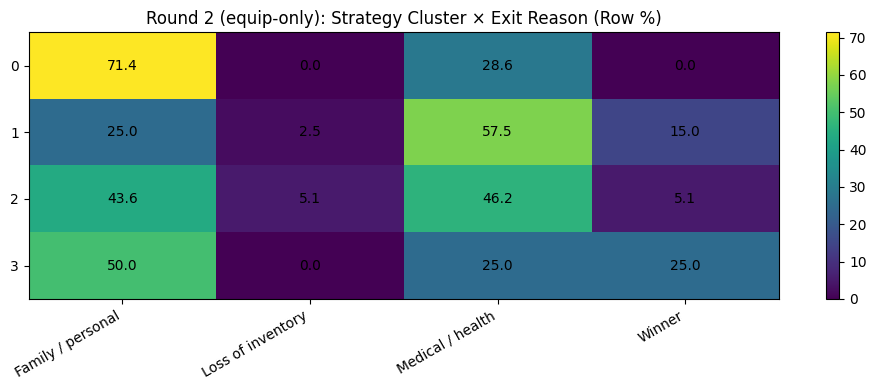

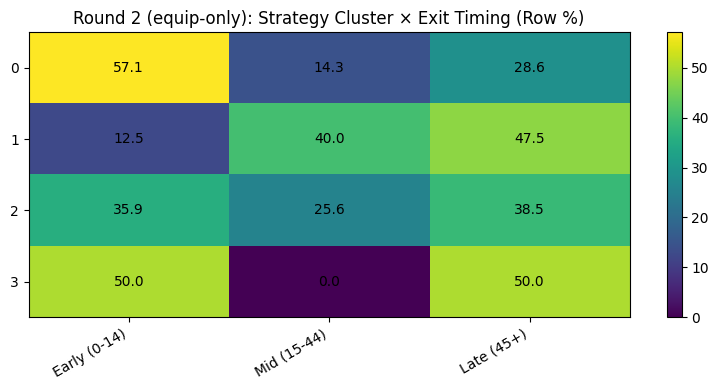

In [46]:
# Round 2 heatmaps
_, r2_reason_rowpct = crosstab_rowpct(df_cross_r2, "strategy_cluster", "reason_category")
_, r2_timing_rowpct = crosstab_rowpct(df_cross_r2, "strategy_cluster", "days_lasted_bin")

plot_heatmap(r2_reason_rowpct.round(1),
             "Round 2 (equip-only): Strategy Cluster × Exit Reason (Row %)",
             figsize=(10, 4))

plot_heatmap(r2_timing_rowpct.round(1),
             "Round 2 (equip-only): Strategy Cluster × Exit Timing (Row %)",
             figsize=(8, 4))

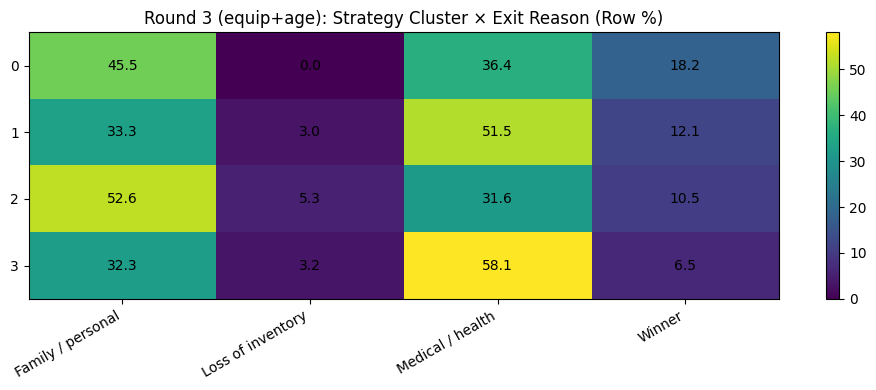

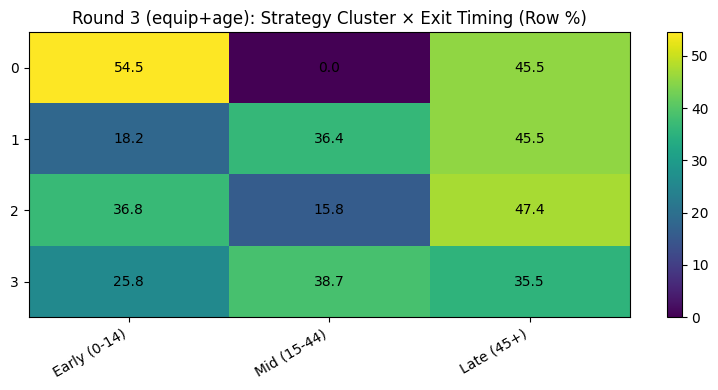

In [47]:
# Round 3 heatmaps
_, r3_reason_rowpct = crosstab_rowpct(df_cross_r3, "strategy_cluster", "reason_category")
_, r3_timing_rowpct = crosstab_rowpct(df_cross_r3, "strategy_cluster", "days_lasted_bin")

plot_heatmap(r3_reason_rowpct.round(1),
             "Round 3 (equip+age): Strategy Cluster × Exit Reason (Row %)",
             figsize=(10, 4))

plot_heatmap(r3_timing_rowpct.round(1),
             "Round 3 (equip+age): Strategy Cluster × Exit Timing (Row %)",
             figsize=(8, 4))

The heatmaps visualize row-level proportions of exit categories within each strategy cluster.

Under equipment-only segmentation (Round 2), mild variation appears in exit timing distributions, consistent with marginal statistical evidence (p ≈ 0.04). However, exit reasons show no clear structural concentration.

Under equipment + age segmentation (Round 3), both reason and timing distributions appear more uniform across clusters. The earlier timing signal weakens and becomes statistically non-significant.

The visual evidence aligns with chi-square results and reinforces the conclusion that any association between strategy clusters and exit pathways is segmentation-sensitive and not robust.


## Section 5 — Exploratory Extension: Audience-Level Structure Beyond Participant Clusters - (George)  
- Sections 1–4 reveal a consistent pattern:
loadout-based strategy clusters exhibit weak separation (silhouette ≈ 0.22), are partially method-dependent (ARI = 0.34), and do not strongly associate with exit pathways (chi-square not significant).

- This raises a natural question: If strategy structure is diffuse at the participant level, might meaningful structure emerge at a higher aggregation level?

George’s M2 clusters episodes using *audience/engagement metrics* (`viewers`, `imdb_rating`, `n_ratings`).
However, the `survivalists.csv` table has **no episode-level key** (no `exit_episode`, `episode_id`, etc.), so we cannot join episode clusters directly to each participant’s outcome.

we use a **season-level bridge**:
1) Cluster episodes (episode-level).
2) Aggregate episode-cluster composition and engagement statistics **by season**.
3) Compare these season-level “audience signatures” with season-level participant outcomes (average `days_lasted`, medical evacuation rate, etc.).

This approach shifts the analytical lens:
- Sections 1–4: participant-level structure
- Section 6: macro-level (season-level) structure

Rather than contradicting earlier findings, this extension tests whether structural signal may reside at a broader narrative or production level rather than within individual loadout choices.


In [48]:
ep_season = episodes[["season","viewers","imdb_rating","n_ratings"]].apply(pd.to_numeric, errors="coerce").dropna()
print("episodes rows:", len(episodes), "usable rows:", len(ep_season))
ep_season["season"] = ep_season["season"].astype(int)

episodes rows: 98 usable rows: 83


In [49]:
season_audience = (
    ep_season.groupby("season").agg(
                 ep_count=("season","size"),
                 viewers_mean=("viewers","mean"),
                 rating_mean=("imdb_rating","mean"),
                 n_ratings_mean=("n_ratings","mean"),).reset_index().sort_values("season")
)
season_audience

,season,ep_count,viewers_mean,rating_mean,n_ratings_mean
0,1,10,1.969700,7.670000,101.800000
1,2,13,1.619077,7.592308,66.769231
2,3,10,1.720400,7.820000,61.200000
3,4,10,1.512200,7.300000,47.900000
4,5,10,1.420400,8.000000,51.400000
5,6,11,1.224545,8.018182,58.909091
6,7,11,1.306818,8.336364,73.909091
7,8,8,1.461750,7.750000,63.875000


In [50]:
season_part = (
    df_unified.groupby("season")
              .agg(n_participants=("name","size"),
                   days_mean=("days_lasted","mean"),
                   days_median=("days_lasted","median"),
                  med_rate=("medically_evacuated_int","mean"),).reset_index().sort_values("season")
)
season_part

,season,n_participants,days_mean,days_median,med_rate
0,1,10,21.600000,7.0,0.000000
1,2,10,34.400000,28.0,0.100000
2,3,10,54.300000,61.5,0.300000
3,4,14,31.428571,14.0,0.285714
4,5,10,30.100000,31.5,0.300000
5,6,10,45.400000,50.0,0.500000
6,7,10,49.900000,44.0,0.300000
7,8,10,41.200000,30.5,0.300000
8,9,10,46.100000,44.5,0.300000


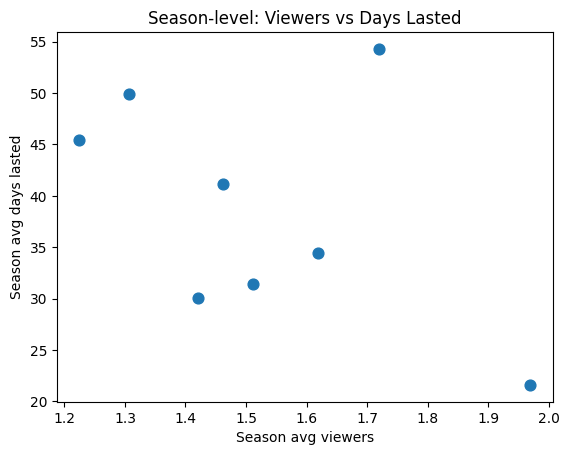

In [51]:
season_audience["season"] = season_audience["season"].astype(int)
season_part["season"] = pd.to_numeric(season_part["season"], errors="coerce").astype(int)
season_integrated = season_audience.merge(season_part, on="season", how="inner").sort_values("season")

plt.figure()
plt.scatter(season_integrated["viewers_mean"], season_integrated["days_mean"], s=60)
plt.xlabel("Season avg viewers")
plt.ylabel("Season avg days lasted")
plt.title("Season-level: Viewers vs Days Lasted")
plt.show()

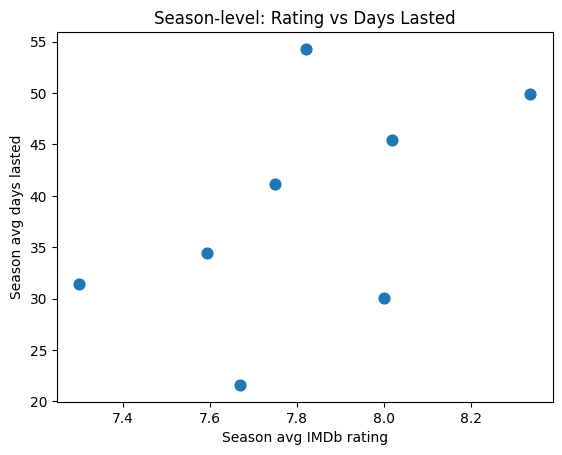

In [52]:
plt.figure()
plt.scatter(season_integrated["rating_mean"], season_integrated["days_mean"], s=60)
plt.xlabel("Season avg IMDb rating")
plt.ylabel("Season avg days lasted")
plt.title("Season-level: Rating vs Days Lasted")
plt.show()

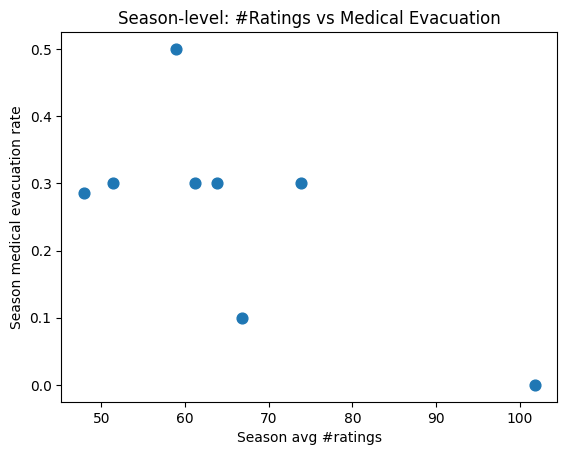

In [53]:
plt.figure()
plt.scatter(season_integrated["n_ratings_mean"], season_integrated["med_rate"], s=60)
plt.xlabel("Season avg #ratings")
plt.ylabel("Season medical evacuation rate")
plt.title("Season-level: #Ratings vs Medical Evacuation")
plt.show()

### Integration Finding

- Overall, the scatterplots suggest that audience engagement and survival outcomes are only weakly aligned at the season level. This mirrors earlier findings at the participant level, where loadout-based strategy clusters exhibited limited structural strength and weak association with exit pathways.

- Taken together, structure appears diffuse both at the micro (participant) and macro (season) levels. Engagement dynamics may reflect broader narrative, production, or contextual factors rather than discrete strategic archetypes.


## Conclusion / Takeaways

1) **Resolving the M2 contradiction:** Under a unified pipeline, method choice (Jaccard+hierarchical vs Euclidean+KMeans) and feature choices (adding age) can materially affect clustering results, which explains why M2 produced conflicting conclusions.

2) **Emergent integration finding:** Overlaying strategy clusters with exit pathway labels provides direct evidence about whether “strategy types” align with exit mechanisms. This question did not exist in M2 and emerged only through integration.

3) **Practical implication:** Because no statistically significant association is detected, exit mechanisms appear not to be strongly determined by strategy cluster membership.
